# DME Coverage Analysis — Switzerland
## Distance Measuring Equipment (DME) Signal Coverage Simulation

This notebook analyzes the signal coverage of DME navigation aids in Switzerland.  
It combines:
- Official DME station data from the **EAD** (European AIS Database)
- Swiss **terrain elevation data** (DEM / GeoTIFF)
- **Free-Space Path Loss (FSPL / Friis)** radio propagation modeling
- **Line-of-Sight (LOS) ray tracing** with Numba JIT acceleration

**Goal:** Determine which areas of Switzerland are reachable by 0, 1, 2, 3 or more DME stations simultaneously at a given flight altitude — i.e., compute a DME redundancy coverage map.


---
## 1. Load and Prepare DME Station Data

The raw data is sourced from an EAD HTML report.  
`pandas.read_html()` extracts all HTML tables; table index `[1]` contains the DME list.  
The first row of that table holds the actual column headers, so we promote it and drop it from the data rows.


In [1]:
import pandas as pd

# Read all HTML tables from the EAD SDO report
tables = pd.read_html("SDO Reporting - DME.html")

# Select the second table (index 1) which contains the DME station list
df = tables[1].copy()

# Promote the first data row to column headers
df.columns = df.iloc[0]   # Use first row as column names
df = df.iloc[1:]           # Remove the header row from data
df = df.reset_index(drop=True)  # Reset the integer index
df

,Master gUID,Identification,Name,Responsible State,Latitude,Longitude,Collocated VOR - Identification,Channel,Frequency of virtual VHF facility,UOM,Datum,Working hours,Effective date,Originator
0,4901516,VO,PRAHA/VODOCHODY DME 28,AERO VODOCHODY AEROSPACE A.S.,50.2160306N,014.4086083E,NaN,44Y,NaN,NaN,WGE,NaN,13/07/2023,EUROCONTROL NMOC
1,400003179939971,AHR,HERAT,AFGHANISTAN,341225.0N,0621358.0E,AHR,109X,NaN,NaN,WGE,NaN,15/08/2019,EUROCONTROL NMOC
2,1660911725,AMS,MAZAR E SHARIF,AFGHANISTAN,364207.6N,0671240.5E,AMS,115X,NaN,NaN,WGE,NaN,20/10/2013,EUROCONTROL NMOC
3,224584313,KBL,KABUL,AFGHANISTAN,3432.73N,06917.42E,KBL,57X,NaN,NaN,WGE,NaN,30/06/2023,EUROCONTROL NMOC
4,1506537395,KDR,KANDAHAR,AFGHANISTAN,312939.3N,0654930.8E,KDR,107X,NaN,NaN,WGE,NaN,18/04/2024,EUROCONTROL NMOC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4658,400002783419683,VFA,VICTORIA FALLS,ZIMBABWE,180524.13S,0254851.60E,VFA,114X,NaN,NaN,WGE,NaN,21/08/2018,EUROCONTROL NMOC
4659,400003257415680,VGO,GOKWE,ZIMBABWE,181440S,0285811E,VGO,84X,NaN,NaN,WGE,NaN,07/10/2019,EUROCONTROL NMOC
4660,400002569849781,VHA,HARARE,ZIMBABWE,175425.86S,0310706.74E,VHA,78X,NaN,NaN,WGE,H24,17/08/2018,EUROCONTROL NMOC
4661,400002568061405,VMV,MASVINGO,ZIMBABWE,200324.4S,0305113.0E,VMV,98X,NaN,NaN,WGE,NaN,01/02/2018,EUROCONTROL NMOC


---
## 2. Parse Coordinates

EAD exports coordinates in two possible formats:
- **Decimal degrees with cardinal**, e.g. `"50.2160306N"`
- **DMS (Degrees Minutes Seconds) packed as integer**, e.g. `"472759.6N"` or `"0073955.6E"`

The `parse_coord()` function handles both formats and returns a signed float in decimal degrees (negative for South / West).

**DMS → Decimal Degrees formula:**
$$DD = \text{deg} + \frac{\text{min}}{60} + \frac{\text{sec}}{3600}$$


In [2]:
import plotly.express as px
import plotly.offline as pyo


def parse_coord(coord, is_lon=False):
    """
    Parse a raw EAD coordinate string into decimal degrees.

    Parameters
    ----------
    coord   : str or float
        Raw coordinate value from the dataframe column.
    is_lon  : bool
        True for longitude (3-digit degree prefix), False for latitude (2-digit).

    Returns
    -------
    float or None
        Decimal degrees, or None if the value cannot be parsed.
    """
    if pd.isna(coord):
        return None

    coord = str(coord).strip()
    direction = None

    # Extract the cardinal direction suffix (N / S / E / W)
    if coord[-1].upper() in "NSEW":
        direction = coord[-1].upper()
        coord = coord[:-1]  # Strip the direction character

    value = float(coord)

    # ── Branch 1: Already in decimal degrees ──────────────────────────────
    # A small value with a decimal point indicates decimal degrees, not DMS.
    if (is_lon and abs(value) <= 180 and "." in coord and value < 1000) or \
       (not is_lon and abs(value) <= 90 and "." in coord and value < 100):
        dd = value

    # ── Branch 2: DMS packed format — convert to decimal degrees ──────────
    else:
        # Remove the decimal separator to work with a pure digit string.
        # Example: "472759.6" → "4727596"
        value_str = coord.replace(".", "")

        if is_lon:
            # Longitude: DDD MM SS.s  (3-digit degrees)
            deg  = int(value_str[:3])
            min_ = int(value_str[3:5])
            sec  = float(value_str[5:]) / (10 ** max(len(value_str[5:]) - 2, 0))
        else:
            # Latitude: DD MM SS.s  (2-digit degrees)
            deg  = int(value_str[:2])
            min_ = int(value_str[2:4])
            sec  = float(value_str[4:]) / (10 ** max(len(value_str[4:]) - 2, 0))

        # Standard DMS → DD conversion
        dd = deg + min_ / 60 + sec / 3600

    # Apply negative sign for southern / western hemisphere
    if direction in ["S", "W"]:
        dd = -dd

    return dd


# Apply the coordinate parser to latitude and longitude columns
df["lat"] = df["Latitude"].apply(lambda x: parse_coord(x, is_lon=False))
df["lon"] = df["Longitude"].apply(lambda x: parse_coord(x, is_lon=True))

# Drop rows where coordinate parsing failed (NaN result)
df = df.dropna(subset=["lat", "lon"])

# Sanity check: remove any values outside the physically valid coordinate range
df = df[df["lat"].between(-90, 90) & df["lon"].between(-180, 180)]

print(f"Valid entries: {len(df)}")

Valid entries: 4663


---
## 3. Filter Swiss DME Stations

The EAD dataset contains DMEs from many countries.  
We keep only stations where the `Responsible State` field indicates a Swiss entity.

The three known values for Switzerland in this dataset are:

| Value | Description |
|---|---|
| `SWITZERLAND` | Generic Swiss state entry |
| `SKYGUIDE` | Swiss ANSP (Air Navigation Service Provider) |
| `FEDERAL OFFICE FOR CIVIL AVIATION` | FOCA / BAZL |


In [3]:
# Keep only Swiss-responsible DME stations
df_ch = df[df["Responsible State"].isin([
    "SWITZERLAND",
    "SKYGUIDE",
    "FEDERAL OFFICE FOR CIVIL AVIATION"
])]

# Interactive Plotly map of all parsed DME locations (sanity check)
fig = px.scatter_mapbox(
    df,
    lat="lat", lon="lon",
    hover_name="Name",
    hover_data={"Identification": True, "Responsible State": True, "lat": False, "lon": False},
    zoom=7,
    center={"lat": 46.8, "lon": 8.3},
    height=700,
    title="DME Locations"
)
fig.update_layout(mapbox_style="carto-positron", hovermode="closest")
fig.update_traces(marker=dict(size=10, color="steelblue"))
pyo.iplot(fig)

C:\Users\kevin\AppData\Local\Temp\ipykernel_23396\3427090934.py:9: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


---
## 4. Classify DME Type and Assign Transmit Power

DMEs fall into two operational categories with different transmit power levels:

| Type | Typical Use | Transmit Power |
|---|---|---|
| **En-Route** | High-altitude navigation | 1 000 W (1 kW) |
| **ILS/Terminal** | Approach / ILS collocated | 100 W |

**Naming convention** in the EAD data:
- Names matching `"DME"` followed by digits (e.g. `"DME 1"`, `"DME 2"`) → ILS/Terminal
- All other entries → En-Route


In [4]:
import re


def classify_dme(name):
    """Return 'ILS/Terminal' if the station name matches the ILS pattern, else 'En-Route'."""
    if re.search(r"DME\s*\d+", str(name), re.IGNORECASE):
        return "ILS/Terminal"
    return "En-Route"


def transmit_power(name):
    """Return transmit power in Watts based on DME type (ILS=100 W, En-Route=1000 W)."""
    if re.search(r"DME\s*\d+", str(name), re.IGNORECASE):
        return 100   # ILS / Terminal DME — 100 W
    return 1000      # En-Route DME — 1 kW


df_ch["DME Type"]           = df_ch["Name"].apply(classify_dme)
df_ch["Transmit Power (W)"] = df_ch["Name"].apply(transmit_power)

# Color-coded map: blue = En-Route, red = ILS/Terminal
fig = px.scatter_mapbox(
    df_ch, lat="lat", lon="lon",
    hover_name="Name",
    color="DME Type",
    color_discrete_map={"En-Route": "steelblue", "ILS/Terminal": "crimson"},
    hover_data={"Identification": True, "Responsible State": True,
                "DME Type": True, "Transmit Power (W)": True, "lat": False, "lon": False},
    zoom=7, center={"lat": 46.8, "lon": 8.3},
    height=700, title="EAD DME Locations in Switzerland"
)
fig.update_layout(mapbox_style="carto-positron", hovermode="closest", legend_title_text="DME Type")
fig.update_traces(marker=dict(size=10))
pyo.iplot(fig)

C:\Users\kevin\AppData\Local\Temp\ipykernel_23396\516700205.py:22: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


---
## 5. Free-Space Path Loss — Maximum Range (Friis Transmission Equation)

The **maximum radio range** is derived from the Friis transmission equation by solving for distance $d$:

$$\text{FSPL}_{\max} \, [\text{dB}] = P_{\text{tx}} \, [\text{dBm}] + G_{\text{tx}} + G_{\text{rx}} - L_{\text{sys}} - P_{\text{rx,min}}$$

$$d_{\max} \, [\text{m}] = \frac{\lambda}{4\pi} \cdot 10^{\,\text{FSPL}_{\max} / 20}$$

**Parameters used:**
- Carrier frequency: **1 000 MHz** (L-band, representative DME value, range: 960–1215 MHz)
- Minimum receiver sensitivity: **−79 dBm** (typical airborne DME receiver)
- Antenna gains and system losses: **0 dB** (isotropic, lossless model)


In [5]:
import math


def max_range(
    p_tx_w: float,
    p_rx_min_dbm: float,
    freq_hz: float,
    g_tx_dbi: float = 0.0,
    g_rx_dbi: float = 0.0,
    l_sys_db: float = 0.0,
) -> float:
    """
    Calculate the maximum free-space radio range using the Friis equation.

    Parameters
    ----------
    p_tx_w       : float — Transmit power in Watts [W]
    p_rx_min_dbm : float — Minimum receiver sensitivity in dBm
    freq_hz      : float — Carrier frequency in Hertz [Hz]
    g_tx_dbi     : float — Transmit antenna gain in dBi  (default 0 = isotropic)
    g_rx_dbi     : float — Receive antenna gain in dBi   (default 0 = isotropic)
    l_sys_db     : float — System losses in dB            (default 0)

    Returns
    -------
    float — Maximum range in meters [m]
    """
    # Convert transmit power from Watts to dBm: P_dBm = 10 · log10(P_mW)
    p_tx_dbm = 10 * math.log10(p_tx_w * 1000)

    # Maximum allowable Free-Space Path Loss (link budget)
    fspl_max_db = p_tx_dbm + g_tx_dbi + g_rx_dbi - l_sys_db - p_rx_min_dbm

    # Wavelength: λ = c / f
    c   = 3e8
    lam = c / freq_hz

    # Solve Friis for distance: d = (λ / 4π) · 10^(FSPL / 20)
    d_max_m = (lam / (4 * math.pi)) * 10 ** (fspl_max_db / 20)

    return d_max_m


# ── Global RF parameters ───────────────────────────────────────────────────
FREQ_HZ      = 1000e6  # 1000 MHz (L-band)
P_RX_MIN_DBM = -79     # −79 dBm minimum receiver sensitivity

# Apply the range formula to each Swiss DME station
df_ch["Max Range (m)"]  = df_ch["Transmit Power (W)"].apply(
    lambda p: max_range(p_tx_w=float(p), p_rx_min_dbm=P_RX_MIN_DBM, freq_hz=FREQ_HZ)
)
df_ch["Max Range (km)"] = df_ch["Max Range (m)"] / 1000

df_ch.head()

,Master gUID,Identification,Name,Responsible State,Latitude,Longitude,Collocated VOR - Identification,Channel,Frequency of virtual VHF facility,UOM,Datum,Working hours,Effective date,Originator,lat,lon,DME Type,Transmit Power (W),Max Range (m),Max Range (km)
1517,97429510,CVA,CORVATSCH,FEDERAL OFFICE FOR CIVIL AVIATION,46.41811251N,009.82158821E,NaN,57Y,NaN,NaN,WGE,NaN,10/07/2025,EUROCONTROL NMOC,46.418113,9.821588,En-Route,1000,212770.488509,212.770489
1518,97429614,LAP,LA PRAZ,FEDERAL OFFICE FOR CIVIL AVIATION,46.67624778N,006.41323194E,NaN,43Y,NaN,NaN,WGE,NaN,10/07/2025,EUROCONTROL NMOC,46.676248,6.413232,En-Route,1000,212770.488509,212.770489
1519,400005408985028,LDL,LA DOLE,FEDERAL OFFICE FOR CIVIL AVIATION,46.42461111N,006.09897222E,NaN,106X,NaN,NaN,WGE,NaN,10/07/2025,EUROCONTROL NMOC,46.424611,6.098972,En-Route,1000,212770.488509,212.770489
1520,400005408985068,PEL,MT. PELERIN,FEDERAL OFFICE FOR CIVIL AVIATION,46.49707556N,006.81913306E,NaN,55Y,NaN,NaN,WGE,NaN,10/07/2025,EUROCONTROL NMOC,46.497076,6.819133,En-Route,1000,212770.488509,212.770489
1521,708737296,WFJ,WEISSFLUHGIPFEL,FEDERAL OFFICE FOR CIVIL AVIATION,46.83457263N,009.79513508E,NaN,84Y,NaN,NaN,WGE,NaN,10/07/2025,EUROCONTROL NMOC,46.834573,9.795135,En-Route,1000,212770.488509,212.770489


---
## 6. Visualize Range Circles on an Interactive Map

For each DME we approximate its theoretical maximum range as a **circle on the Earth's surface**  
(flat-Earth great-circle approximation — valid for distances < ~500 km).

$$\Delta\text{lat} = \frac{r}{R_\oplus} \cdot \cos(\theta) \qquad \Delta\text{lon} = \frac{r}{R_\oplus \cdot \cos(\phi)} \cdot \sin(\theta)$$

A single representative En-Route DME is shown first to verify the geometry.


In [6]:
import plotly.graph_objects as go
import numpy as np


def range_circle(lat, lon, radius_m, n_points=360):
    """
    Generate lat/lon coordinates of a circle around a given point.

    Parameters
    ----------
    lat      : float — Center latitude [decimal degrees]
    lon      : float — Center longitude [decimal degrees]
    radius_m : float — Circle radius [meters]
    n_points : int   — Angular resolution (number of interpolation points)

    Returns
    -------
    tuple (list[float], list[float]) — (latitudes, longitudes)
    """
    R = 6_371_000  # Mean Earth radius [m]
    lats, lons = [], []

    for angle in np.linspace(0, 2 * np.pi, n_points):
        d_lat = (radius_m / R) * np.cos(angle) * (180 / np.pi)
        d_lon = (radius_m / R) * np.sin(angle) / np.cos(np.radians(lat)) * (180 / np.pi)
        lats.append(lat + d_lat)
        lons.append(lon + d_lon)

    # Close the circle by repeating the first point
    lats.append(lats[0])
    lons.append(lons[0])
    return lats, lons


# Select one example En-Route DME (index 5)
dme = df_ch[df_ch["DME Type"] == "En-Route"].iloc[0]
circle_lats, circle_lons = range_circle(dme["lat"], dme["lon"], dme["Max Range (m)"])

fig1 = go.Figure()

# Outline ring
fig1.add_trace(go.Scattermapbox(
    lat=circle_lats, lon=circle_lons, mode="lines",
    line=dict(color="steelblue", width=2),
    name=f"Max Range: {dme['Max Range (km)']:.1f} km", hoverinfo="skip"
))

# Semi-transparent filled coverage area
fig1.add_trace(go.Scattermapbox(
    lat=circle_lats, lon=circle_lons, mode="lines",
    fill="toself", fillcolor="rgba(70, 130, 180, 0.15)",
    line=dict(width=0), name="Coverage Area", hoverinfo="skip"
))

# DME station marker
fig1.add_trace(go.Scattermapbox(
    lat=[dme["lat"]], lon=[dme["lon"]], mode="markers",
    marker=dict(size=12, color="steelblue"), name=dme["Name"],
    hovertemplate=(
        f"<b>{dme['Name']}</b><br>ID: {dme['Identification']}<br>"
        f"Type: {dme['DME Type']}<br>Power: {dme['Transmit Power (W)']} W<br>"
        f"Max Range: {dme['Max Range (km)']:.1f} km<extra></extra>"
    )
))

fig1.update_layout(
    mapbox_style="carto-positron",
    mapbox=dict(center={"lat": dme["lat"], "lon": dme["lon"]}, zoom=6),
    height=700,
    title=f"DME Maximum Range — {dme['Name']} ({dme['Identification']})",
    legend_title_text="Legend", hovermode="closest"
)
pyo.iplot(fig1)

C:\Users\kevin\AppData\Local\Temp\ipykernel_23396\3700889592.py:42: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig1.add_trace(go.Scattermapbox(
C:\Users\kevin\AppData\Local\Temp\ipykernel_23396\3700889592.py:49: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig1.add_trace(go.Scattermapbox(
C:\Users\kevin\AppData\Local\Temp\ipykernel_23396\3700889592.py:56: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig1.add_trace(go.Scattermapbox(


---
## 7. All Swiss DMEs — Range Circle Overview Map

All Swiss DME stations are plotted simultaneously with their theoretical range circles.  
This gives a flat-Earth coverage overview **without** terrain effects (no LOS check yet).

- 🔵 **Blue** — En-Route DMEs (1 kW, larger circles)  
- 🔴 **Red** — ILS/Terminal DMEs (100 W, smaller circles)


In [7]:
fig2 = go.Figure()

color_map    = {"En-Route": "steelblue",             "ILS/Terminal": "crimson"}
fill_map     = {"En-Route": "rgba(70,130,180,0.08)", "ILS/Terminal": "rgba(220,20,60,0.08)"}
shown_legend = set()  # Track which legend entries have been added (avoid duplicates)

# Draw one filled range circle per DME station
for _, row in df_ch.iterrows():
    dme_type = row["DME Type"]
    color    = color_map.get(dme_type, "gray")
    fill     = fill_map.get(dme_type, "rgba(128,128,128,0.08)")
    c_lats, c_lons = range_circle(row["lat"], row["lon"], row["Max Range (m)"])

    fig2.add_trace(go.Scattermapbox(
        lat=c_lats, lon=c_lons, mode="lines",
        fill="toself", fillcolor=fill, line=dict(color=color, width=1),
        name=dme_type, legendgroup=dme_type,
        showlegend=(dme_type not in shown_legend),  # Only first entry per type in legend
        hovertemplate=(
            f"<b>{row['Name']}</b><br>ID: {row['Identification']}<br>"
            f"Type: {dme_type}<br>Power: {row['Transmit Power (W)']} W<br>"
            f"Max Range: {row['Max Range (km)']:.1f} km<extra></extra>"
        )
    ))
    shown_legend.add(dme_type)

# Overlay station markers on top of the range circles
for dme_type, group in df_ch.groupby("DME Type"):
    color = color_map.get(dme_type, "gray")
    fig2.add_trace(go.Scattermapbox(
        lat=group["lat"], lon=group["lon"], mode="markers",
        marker=dict(size=8, color=color),
        name=f"{dme_type} (Station)", legendgroup=dme_type, showlegend=False,
        customdata=group[["Identification", "Transmit Power (W)", "Max Range (km)"]].values,
        hovertemplate=(
            "<b>%{hovertext}</b><br>ID: %{customdata[0]}<br>"
            f"Type: {dme_type}<br>Power: %{{customdata[1]}} W<br>"
            "Max Range: %{customdata[2]:.1f} km<extra></extra>"
        ),
        hovertext=group["Name"]
    ))

fig2.update_layout(
    mapbox_style="carto-positron",
    mapbox=dict(center={"lat": 46.8, "lon": 8.3}, zoom=7),
    height=700, title="EAD DME — Maximum Ranges in Switzerland",
    legend_title_text="DME Type", hovermode="closest"
)
pyo.iplot(fig2)

C:\Users\kevin\AppData\Local\Temp\ipykernel_23396\2171117771.py:14: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig2.add_trace(go.Scattermapbox(
C:\Users\kevin\AppData\Local\Temp\ipykernel_23396\2171117771.py:30: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig2.add_trace(go.Scattermapbox(
C:\Users\kevin\AppData\Local\Temp\ipykernel_23396\2171117771.py:30: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig2.add_trace(go.Scattermapbox(


---
## 8. Load Terrain Elevation Data (DEM / GeoTIFF)

A Digital Elevation Model (DEM) of Switzerland is loaded from a GeoTIFF file using `rasterio`.

| Variable | Content |
|---|---|
| `terrain` | 2-D NumPy array of elevation values [m] |
| `transform` | Affine transform mapping pixel indices ↔ geographic coordinates |
| `bounds` | Spatial bounding box (left, bottom, right, top) |


In [8]:
import rasterio
import numpy as np

with rasterio.open("schweiz_terrain_master.tif") as src:
    terrain   = src.read(1)    # Read band 1 — elevation in meters
    transform = src.transform  # Affine transform: pixel ↔ geographic coordinates
    crs       = src.crs        # Coordinate Reference System (e.g. EPSG:4326)
    bounds    = src.bounds     # Spatial extent of the raster

print(f"Terrain shape: {terrain.shape}")
print(f"Bounds: {bounds}")

Terrain shape: (10801, 21601)
Bounds: BoundingBox(left=4.9998611111111115, bottom=44.99986111111111, right=11.00013888888889, top=48.000138888888884)


---
## 9. Sample Terrain Elevation at DME Station Locations

Each station's (lon, lat) coordinates are converted to raster pixel indices via `rasterio.rowcol()`,  
then the corresponding elevation is read from the DEM array.

A fixed **antenna height of +20 m** is added to represent the DME transmitter mounted  
on a mast or building above the ground surface.


In [9]:
from rasterio.transform import rowcol

# Convert (lon, lat) geographic coordinates to (row, col) raster pixel indices
rows, cols = rowcol(transform, df_ch["lon"].values, df_ch["lat"].values)

# Clamp indices to stay within raster bounds (handles edge cases near the border)
rows = np.clip(rows, 0, terrain.shape[0] - 1)
cols = np.clip(cols, 0, terrain.shape[1] - 1)

# Sample elevation and assign to dataframe
df_ch["Elevation (m)"] = terrain[rows, cols].astype(float)

# Mask out NoData values (typically large negative numbers in DEMs)
df_ch["Elevation (m)"] = df_ch["Elevation (m)"].where(df_ch["Elevation (m)"] > -500, np.nan)

# Add antenna height offset: 20 m above terrain
df_ch["Elevation (m)"] = df_ch["Elevation (m)"] + 20

df_ch[["Name", "Identification", "DME Type", "Elevation (m)"]].head()

,Name,Identification,DME Type,Elevation (m)
1517,CORVATSCH,CVA,En-Route,3312.0
1518,LA PRAZ,LAP,En-Route,1309.0
1519,LA DOLE,LDL,En-Route,1682.0
1520,MT. PELERIN,PEL,En-Route,1122.0
1521,WEISSFLUHGIPFEL,WFJ,En-Route,2838.0


---
## 10. Build the Analysis Grid

A uniform geographic grid (**500 × 500 points**) is created over the bounding box of the Swiss DEM.  
Each grid cell represents one potential aircraft position for which we evaluate DME signal availability.

> **Resolution note:** At 500×500 over Switzerland (~280 km × 220 km), the grid spacing is roughly **0.5–0.6 km**.  
> Increase `GRID_SIZE` for higher resolution (at the cost of longer computation time).


In [10]:
# ── Grid parameters ────────────────────────────────────────────────────────
GRID_SIZE = 500  # Number of grid points along each axis (NxN grid)

# Create 1-D coordinate arrays spanning the raster bounding box
lat_grid = np.linspace(bounds.top,  bounds.bottom, GRID_SIZE)  # North → South
lon_grid = np.linspace(bounds.left, bounds.right,  GRID_SIZE)  # West  → East

# Create 2-D meshgrid: lon_mesh[i,j] / lat_mesh[i,j] are the grid point coordinates
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

print(f"Grid shape: {lon_mesh.shape}  |  Total grid points: {GRID_SIZE**2:,}")

Grid shape: (500, 500)  |  Total grid points: 250,000


---
## 11. Sample Terrain Elevation on the Grid

The same `rowcol()` lookup is applied to all grid points in bulk (flattened → reshaped).  
Invalid DEM values (water, NoData) are set to `NaN` and treated as sea-level (0 m) during ray tracing.


In [11]:
from rasterio.transform import rowcol

# Convert all grid coordinates to raster pixel indices (bulk lookup via flatten)
rows, cols = rowcol(transform, lon_mesh.flatten(), lat_mesh.flatten())

rows = np.clip(rows, 0, terrain.shape[0] - 1)
cols = np.clip(cols, 0, terrain.shape[1] - 1)

# Sample elevations and reshape back to the 2-D grid
elev_grid = terrain[rows, cols].reshape(GRID_SIZE, GRID_SIZE).astype(float)
elev_grid[elev_grid < -500] = np.nan  # Mask NoData values

---
## 12. Visualize the Terrain Grid

A quick matplotlib plot verifies that the DEM was sampled correctly onto the analysis grid.  
The `"terrain"` colormap maps low elevations to green/blue and high elevations to white/grey.


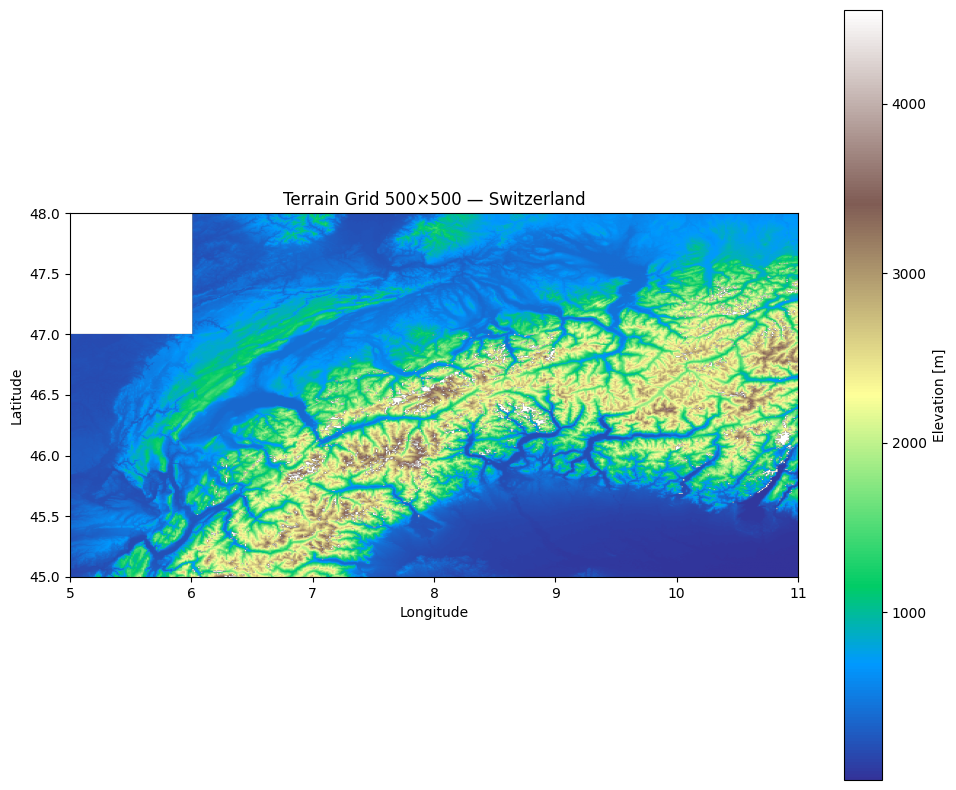

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    elev_grid,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    cmap="terrain", origin="upper"
)
plt.colorbar(im, ax=ax, label="Elevation [m]")
ax.set_title(f"Terrain Grid {GRID_SIZE}×{GRID_SIZE} — Switzerland")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

---
## 13. Line-of-Sight (LOS) Ray Tracing with Numba

For each DME station, a straight ray is traced from the station antenna to every grid point  
at the target flight altitude. A grid point is marked **blocked** if any intermediate terrain  
cell exceeds the linearly interpolated ray altitude at that step.

**Algorithm (per grid point `(i, j)`):**
1. Draw a straight line from DME pixel `(dme_row, dme_col)` to target pixel `(i, j)`.
2. Sample $N = \lceil\sqrt{2} \cdot r\rceil$ intermediate pixels (scales with ray length to avoid gaps).
3. At each step $t \in [0, 1]$: compute ray altitude $= h_{\text{DME}} + t \cdot (h_{\text{target}} - h_{\text{DME}})$.
4. If `terrain[r, c] > ray_altitude` at any step → **blocked** (LOS = False).

**Performance:** `@njit(parallel=True)` (Numba) gives ~50–100× speed-up over pure Python.

**Target altitude:** **10 000 ft (3 048 m)** — typical en-route cruise altitude in Swiss airspace.


In [13]:
from numba import njit, prange
import numba as nb

# ── Flight altitude parameter ──────────────────────────────────────────────
FLIGHT_ALT_FT = 10_000
FLIGHT_ALT_M  = FLIGHT_ALT_FT * 0.3048  # Convert feet to meters


@njit(parallel=True, cache=True)
def compute_los_grid_numba(elev_grid, dme_row, dme_col, dme_elev_m, target_alt_m, grid_size):
    """
    Numba JIT-compiled ray tracing — compute LOS from one DME to all grid points.

    The step count scales with ray length (√2 · length) to ensure every grid
    cell along the path is visited (avoids the staircase aliasing artifact).

    Parameters
    ----------
    elev_grid    : 2-D float64 array  — terrain elevation [m]  (GRID_SIZE × GRID_SIZE)
    dme_row      : int   — DME station row index in the grid
    dme_col      : int   — DME station column index in the grid
    dme_elev_m   : float — DME antenna elevation above sea level [m]
    target_alt_m : float — Aircraft altitude above sea level [m]
    grid_size    : int   — Grid dimension N

    Returns
    -------
    los_grid : 2-D boolean array (GRID_SIZE × GRID_SIZE)
        True  → line-of-sight clear  |  False → terrain blocks the ray
    """
    los_grid = np.ones((grid_size, grid_size), dtype=nb.boolean)

    for i in prange(grid_size):          # prange → parallel outer loop
        for j in range(grid_size):

            # Scale steps to ray length to avoid sampling gaps
            ray_len = np.sqrt((i - dme_row)**2 + (j - dme_col)**2)
            n_steps = max(int(np.sqrt(2.0) * ray_len), 1)

            blocked = False
            for s in range(n_steps + 1):
                t = s / n_steps  # Normalized progress along the ray [0 → 1]

                # Interpolated pixel coordinates along the ray
                r = int(round(dme_row + t * (i - dme_row)))
                c = int(round(dme_col + t * (j - dme_col)))
                r = min(max(r, 0), grid_size - 1)
                c = min(max(c, 0), grid_size - 1)

                # Ray altitude at this step (linear interpolation)
                alt = dme_elev_m + t * (target_alt_m - dme_elev_m)

                # Terrain height — NaN treated as sea level (0 m)
                terrain_h = elev_grid[r, c]
                if np.isnan(terrain_h):
                    terrain_h = 0.0

                # Ray is blocked if terrain exceeds the ray altitude
                if alt < terrain_h:
                    blocked = True
                    break

            los_grid[i, j] = not blocked

    return los_grid


def compute_los_grid(dme_lat, dme_lon, dme_elev_m, target_alt_m):
    """Wrapper: converts geographic coordinates to grid indices, then calls the Numba kernel."""
    dme_row = int(np.argmin(np.abs(lat_grid - dme_lat)))
    dme_col = int(np.argmin(np.abs(lon_grid - dme_lon)))
    return compute_los_grid_numba(
        elev_grid.astype(np.float64),
        dme_row, dme_col,
        float(dme_elev_m), float(target_alt_m),
        GRID_SIZE
    )


# ── Trigger JIT compilation with a warm-up call ───────────────────────────
print("Compiling Numba kernel (first call triggers JIT compilation)...")
_ = compute_los_grid(df_ch.iloc[0]["lat"], df_ch.iloc[0]["lon"],
                     df_ch.iloc[0]["Elevation (m)"], FLIGHT_ALT_M)
print("Compilation done. Running LOS for all DME stations...\n")

# ── Compute LOS grid for every Swiss DME station ──────────────────────────
# Result shape: (n_dme, GRID_SIZE, GRID_SIZE) — one boolean map per station
los_all = np.zeros((len(df_ch), GRID_SIZE, GRID_SIZE), dtype=bool)

for i, (_, dme) in enumerate(df_ch.iterrows()):
    los_all[i] = compute_los_grid(
        dme_lat=dme["lat"], dme_lon=dme["lon"],
        dme_elev_m=dme["Elevation (m)"], target_alt_m=FLIGHT_ALT_M
    )
    print(f"[{i+1:02d}/{len(df_ch)}] {dme['Name']:<30} LOS coverage: {los_all[i].mean()*100:.1f}%")

print(f"\nAll done. Shape: {los_all.shape}  →  (n_dme={len(df_ch)}, {GRID_SIZE}×{GRID_SIZE})")

Compiling Numba kernel (first call triggers JIT compilation)...
Compilation done. Running LOS for all DME stations...

[01/27] CORVATSCH                      LOS coverage: 52.8%
[02/27] LA PRAZ                        LOS coverage: 56.0%
[03/27] LA DOLE                        LOS coverage: 58.7%
[04/27] MT. PELERIN                    LOS coverage: 36.6%
[05/27] WEISSFLUHGIPFEL                LOS coverage: 46.5%
[06/27] DME 10 SGA                     LOS coverage: 17.6%
[07/27] DME 14 BRN                     LOS coverage: 9.1%
[08/27] DME 29 DUB                     LOS coverage: 19.2%
[09/27] DME 22 EMM                     LOS coverage: 14.4%
[10/27] DME 14 ZRH                     LOS coverage: 23.4%
[11/27] DME 01 LUG                     LOS coverage: 1.6%
[12/27] DME 04 GVA                     LOS coverage: 25.1%
[13/27] DME 05 PAY                     LOS coverage: 30.4%
[14/27] DME 23 PAY                     LOS coverage: 26.0%
[15/27] DME 25 SIO                     LOS coverage: 0.8%

---
## 14. Visualize LOS Coverage for a Single DME (Full Extent)

Two-panel plot for one chosen DME station:
- **Top:** Terrain elevation with antenna position marked (red triangle).
- **Bottom:** LOS overlay — 🟢 green = signal reachable, 🔴 red = terrain blocked.


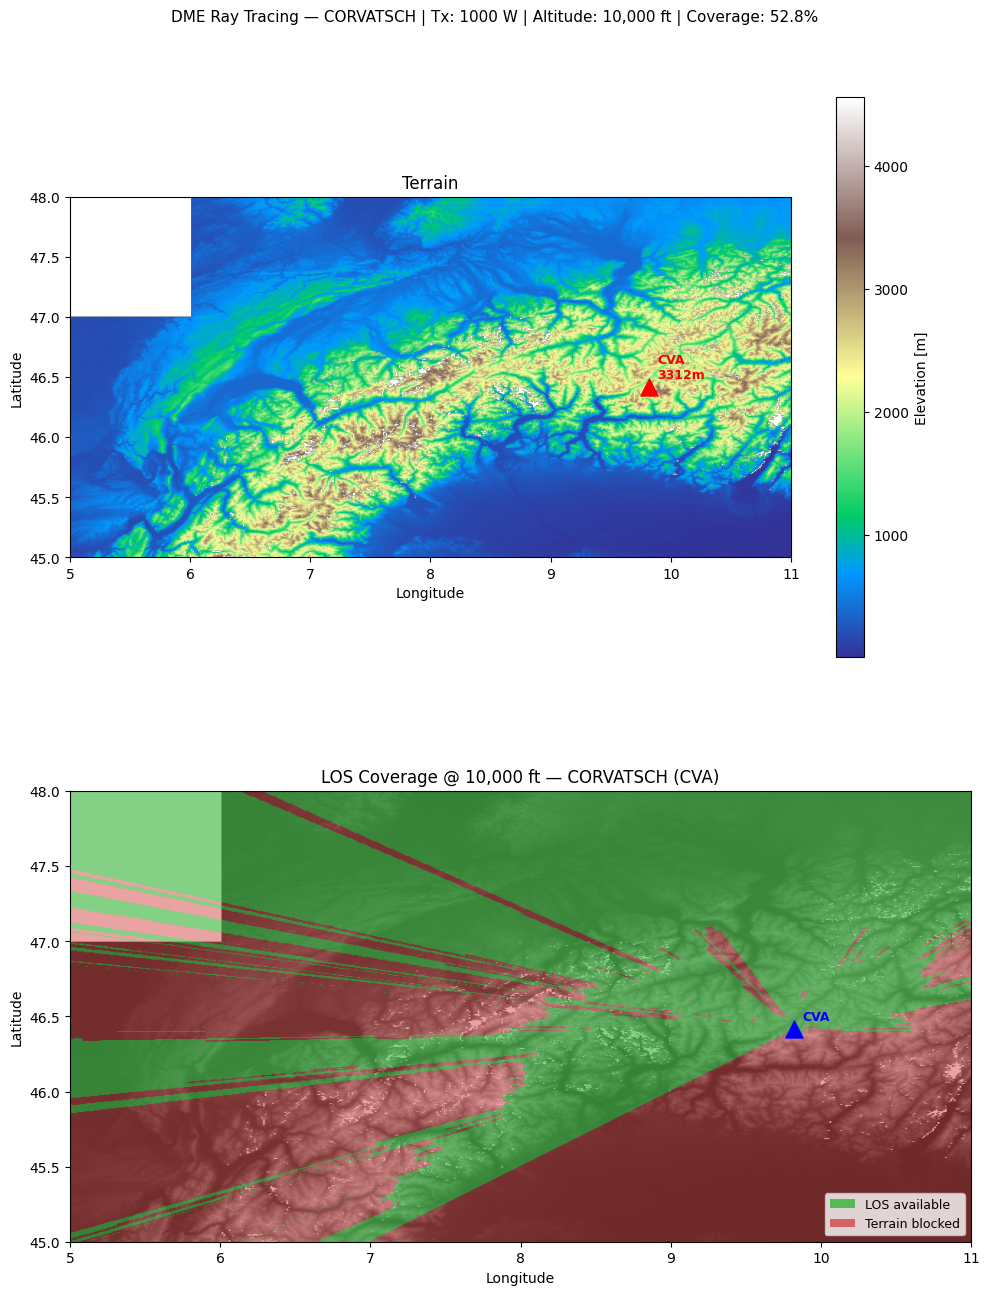

In [14]:
from matplotlib.patches import Patch

dme_idx = 0  # ← Change this index to inspect other stations
dme     = df_ch.iloc[dme_idx]

fig, axes = plt.subplots(2, 1, figsize=(10, 14))

# ── Top panel: Terrain ─────────────────────────────────────────────────────
ax1 = axes[0]
im1 = ax1.imshow(elev_grid,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    cmap="terrain", origin="upper")
ax1.scatter(dme["lon"], dme["lat"], color="red", s=150, zorder=5, marker="^")
ax1.annotate(f"{dme['Identification']}\n{dme['Elevation (m)']:.0f}m",
    (dme["lon"], dme["lat"]), textcoords="offset points", xytext=(6, 6),
    fontsize=9, color="red", fontweight="bold")
plt.colorbar(im1, ax=ax1, label="Elevation [m]", shrink=0.8)
ax1.set_title("Terrain")
ax1.set_xlabel("Longitude"); ax1.set_ylabel("Latitude")

# ── Bottom panel: LOS coverage overlay ────────────────────────────────────
ax2 = axes[1]
ax2.imshow(elev_grid,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    cmap="gray", origin="upper", alpha=0.8)

# RGBA overlay: green = LOS clear, red = blocked
los_rgba = np.zeros((*los_all[dme_idx].shape, 4))
los_rgba[ los_all[dme_idx]] = [0.2, 0.7, 0.2, 0.6]   # Green
los_rgba[~los_all[dme_idx]] = [0.8, 0.1, 0.1, 0.4]   # Red

ax2.imshow(los_rgba,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top], origin="upper")
ax2.scatter(dme["lon"], dme["lat"], color="blue", s=150, zorder=5, marker="^")
ax2.annotate(dme["Identification"], (dme["lon"], dme["lat"]),
    textcoords="offset points", xytext=(6, 6), fontsize=9, color="blue", fontweight="bold")

legend_elements = [
    Patch(facecolor=(0.2, 0.7, 0.2, 0.8), label="LOS available"),
    Patch(facecolor=(0.8, 0.1, 0.1, 0.6), label="Terrain blocked"),
]
ax2.legend(handles=legend_elements, loc="lower right", fontsize=9)
ax2.set_title(f"LOS Coverage @ {FLIGHT_ALT_FT:,} ft — {dme['Name']} ({dme['Identification']})")
ax2.set_xlabel("Longitude"); ax2.set_ylabel("Latitude")

fig.suptitle(
    f"DME Ray Tracing — {dme['Name']} | Tx: {dme['Transmit Power (W)']} W | "
    f"Altitude: {FLIGHT_ALT_FT:,} ft | Coverage: {los_all[dme_idx].mean()*100:.1f}%", fontsize=11)
plt.tight_layout(); plt.show()

---
## 15. Zoomed LOS View — 40 km Radius

The same two-panel plot is repeated with axes restricted to a **40 km bounding box**  
around the DME station, giving a closer look at local terrain shadowing effects  
(mountain valleys, ridge lines, terrain self-shielding).


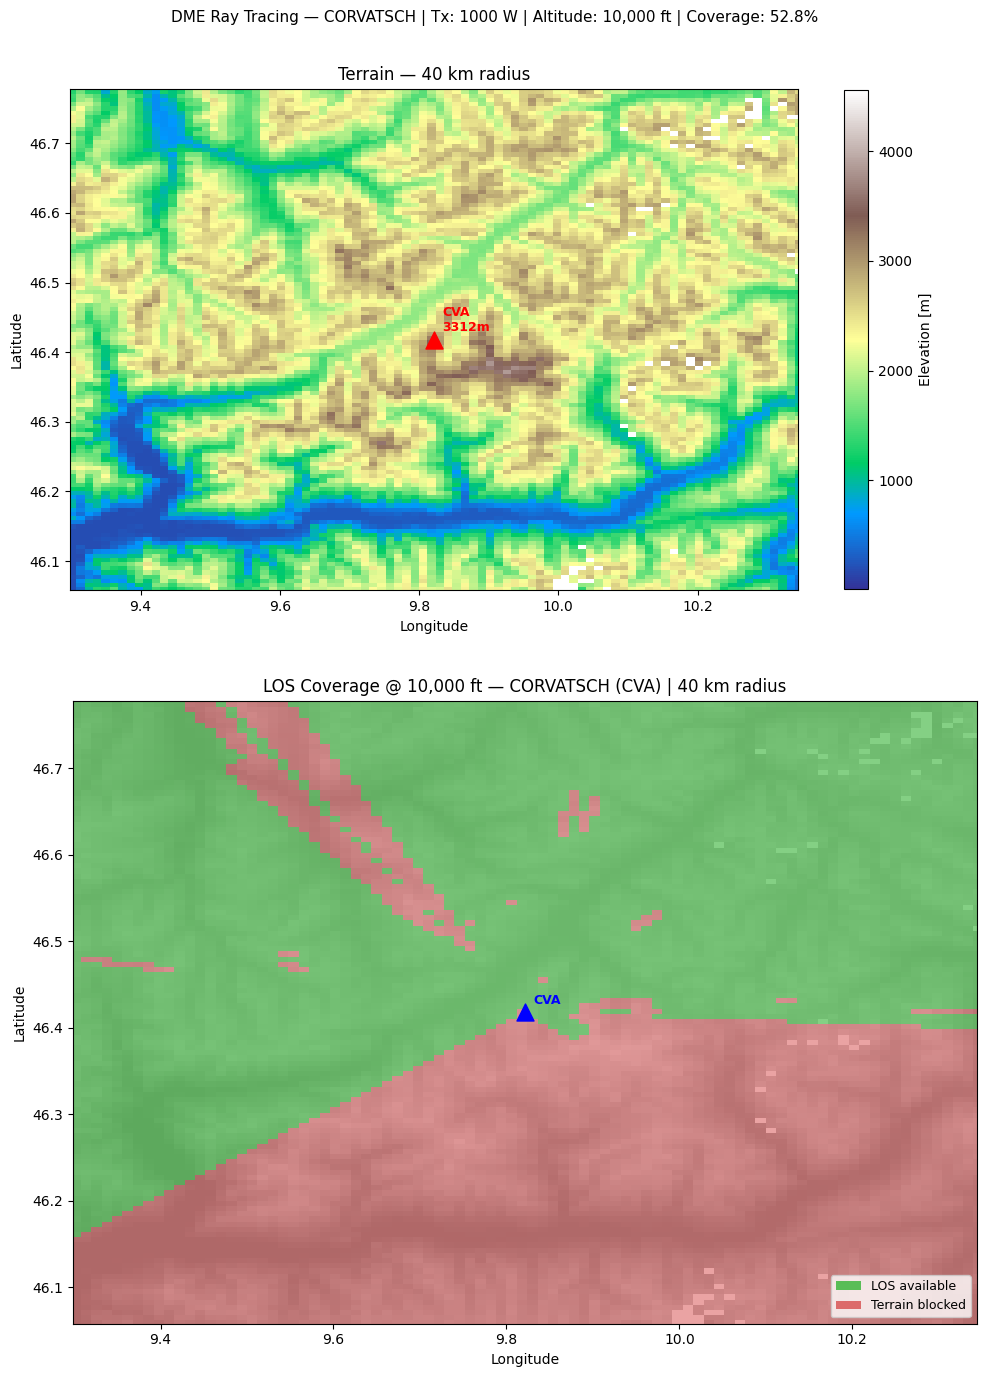

In [15]:
dme_idx   = 0
dme       = df_ch.iloc[dme_idx]
RADIUS_KM = 40  # Half-width of the bounding box in km

# Convert km radius to approximate degree offsets
lat_deg = RADIUS_KM / 111.0                                        # 1° lat ≈ 111 km
lon_deg = RADIUS_KM / (111.0 * np.cos(np.radians(dme["lat"])))   # 1° lon varies with lat

lat_min, lat_max = dme["lat"] - lat_deg, dme["lat"] + lat_deg
lon_min, lon_max = dme["lon"] - lon_deg, dme["lon"] + lon_deg

fig, axes = plt.subplots(2, 1, figsize=(10, 14))

# ── Top panel: Terrain (zoomed) ────────────────────────────────────────────
ax1 = axes[0]
im1 = ax1.imshow(elev_grid,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    cmap="terrain", origin="upper")
ax1.scatter(dme["lon"], dme["lat"], color="red", s=150, zorder=5, marker="^")
ax1.annotate(f"{dme['Identification']}\n{dme['Elevation (m)']:.0f}m",
    (dme["lon"], dme["lat"]), textcoords="offset points", xytext=(6, 6),
    fontsize=9, color="red", fontweight="bold")
plt.colorbar(im1, ax=ax1, label="Elevation [m]", shrink=0.8)
ax1.set_xlim(lon_min, lon_max); ax1.set_ylim(lat_min, lat_max)  # Apply zoom
ax1.set_title(f"Terrain — {RADIUS_KM} km radius")
ax1.set_xlabel("Longitude"); ax1.set_ylabel("Latitude")

# ── Bottom panel: LOS coverage overlay (zoomed) ───────────────────────────
ax2 = axes[1]
ax2.imshow(elev_grid,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    cmap="gray", origin="upper", alpha=0.4)

los_rgba = np.zeros((*los_all[dme_idx].shape, 4))
los_rgba[ los_all[dme_idx]] = [0.2, 0.7, 0.2, 0.6]
los_rgba[~los_all[dme_idx]] = [0.8, 0.1, 0.1, 0.4]

ax2.imshow(los_rgba,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top], origin="upper")
ax2.scatter(dme["lon"], dme["lat"], color="blue", s=150, zorder=5, marker="^")
ax2.annotate(dme["Identification"], (dme["lon"], dme["lat"]),
    textcoords="offset points", xytext=(6, 6), fontsize=9, color="blue", fontweight="bold")
ax2.set_xlim(lon_min, lon_max); ax2.set_ylim(lat_min, lat_max)  # Apply zoom

ax2.legend(handles=legend_elements, loc="lower right", fontsize=9)
ax2.set_title(
    f"LOS Coverage @ {FLIGHT_ALT_FT:,} ft — {dme['Name']} ({dme['Identification']}) "
    f"| {RADIUS_KM} km radius")
ax2.set_xlabel("Longitude"); ax2.set_ylabel("Latitude")

fig.suptitle(
    f"DME Ray Tracing — {dme['Name']} | Tx: {dme['Transmit Power (W)']} W | "
    f"Altitude: {FLIGHT_ALT_FT:,} ft | Coverage: {los_all[dme_idx].mean()*100:.1f}%", fontsize=11)
plt.tight_layout(); plt.show()

---
## 16. DME Redundancy Map — Combined LOS + Range Filter

The final analysis combines **two conditions** that must both be true for a grid point  
to be considered reachable by a given DME:

| Condition | Description |
|---|---|
| ✅ **Line-of-Sight** | No terrain obstruction along the ray (Section 13) |
| ✅ **RF Range** | Grid point lies within the DME's max free-space range (Section 5) |

For each grid point we count how many DMEs simultaneously satisfy both conditions → **redundancy map**:

| Count | Aviation meaning |
|---|---|
| 0 | No DME signal — navigation blind spot |
| 1 | Single point of failure |
| 2 | Minimum redundancy |
| 3 | Good coverage |
| 4+ | Excellent redundancy |

> **Terrain masking:** Grid points where the terrain elevation exceeds the target flight altitude  
> (i.e. the aircraft would be inside a mountain) are marked as `NaN` and excluded from the analysis.  
> Without this mask, such points would always appear as "blocked" — technically correct, but  
> physically meaningless since no aircraft can fly there.

> **Implementation:** Distance is computed for all (DME × grid point) pairs via NumPy broadcasting  
> `(n_dme, 1, 1)` vs `(1, GRID_SIZE, GRID_SIZE)` — no Python loop needed.

In [16]:
# ── Compute distance from every DME to every grid point ───────────────────
lat_center = np.radians(np.mean(df_ch["lat"].values))  # Representative lat for cos() factor

# Δlat in meters — shape broadcast: (n_dme, GRID_SIZE, GRID_SIZE)
d_lat = (lat_mesh[np.newaxis, :, :] - df_ch["lat"].values[:, np.newaxis, np.newaxis]) * 111_000

# Δlon in meters — corrected for latitude (lon degrees shrink toward poles)
d_lon = (lon_mesh[np.newaxis, :, :] - df_ch["lon"].values[:, np.newaxis, np.newaxis]) \
        * 111_000 * np.cos(lat_center)

# Euclidean distance for each (DME, row, col) triple — shape: (n_dme, GRID_SIZE, GRID_SIZE)
dist_grid = np.sqrt(d_lat**2 + d_lon**2)

# ── Boolean range mask: True if grid point is within the DME's max range ──
dme_ranges = df_ch["Max Range (m)"].values
range_mask = dist_grid <= dme_ranges[:, np.newaxis, np.newaxis]

# ── Combine: LOS clear AND within range ───────────────────────────────────
los_and_range = los_all & range_mask  # Shape: (n_dme, GRID_SIZE, GRID_SIZE)

# ── Count reachable DMEs per grid point ───────────────────────────────────
dme_count_grid = los_and_range.sum(axis=0).astype(float)  # float to support NaN

# ── Terrain mask: exclude grid points where terrain exceeds flight altitude ─
# These points lie physically inside a mountain — no aircraft can be there.
# Without this mask they would appear as "blocked" (accidentally correct) but
# clutter the coverage statistics with meaningless data points.
terrain_mask = elev_grid > FLIGHT_ALT_M  # True where terrain elevation > flight altitude MSL
dme_count_grid[terrain_mask] = np.nan    # Mark as invalid / not applicable

# ── Summary statistics (valid airspace points only) ───────────────────────
valid = ~terrain_mask & ~np.isnan(elev_grid)  # Exclude mountains and DEM NoData

print(f"Total grid points:             {GRID_SIZE**2:,}")
print(f"  thereof inside terrain:      {terrain_mask.sum():,}  (excluded)")
print(f"  thereof valid airspace:      {valid.sum():,}")
print(f"Valid points with 0 DMEs:      {(dme_count_grid[valid] == 0).sum():,}")
print(f"Valid points with 1+ DMEs:     {(dme_count_grid[valid] >= 1).sum():,}")
print(f"Max DMEs at a single point:    {np.nanmax(dme_count_grid):.0f}")
print(f"Mean DMEs per reachable point: {np.nanmean(dme_count_grid[dme_count_grid > 0]):.1f}")

Total grid points:             250,000
  thereof inside terrain:      2,211  (excluded)
  thereof valid airspace:      230,014
Valid points with 0 DMEs:      52,786
Valid points with 1+ DMEs:     177,228
Max DMEs at a single point:    19
Mean DMEs per reachable point: 6.9


---
## 17. Single DME — LOS + Range Combined View

Before looking at the full redundancy map, it is useful to verify the combined  
filter (LOS + range) for a **single DME station** in isolation.

The plot shows three layers:
- **Greyscale terrain** — background reference
- **Green** — grid points that are within range AND have line-of-sight → signal reachable
- **Red** — grid points that are either out of range OR terrain-blocked → no signal
- **Light grey** — terrain above flight altitude (physically unreachable)

This is the most honest single-station coverage picture:  
free-space range sets the outer boundary, terrain shadowing carves out the blind spots within it.

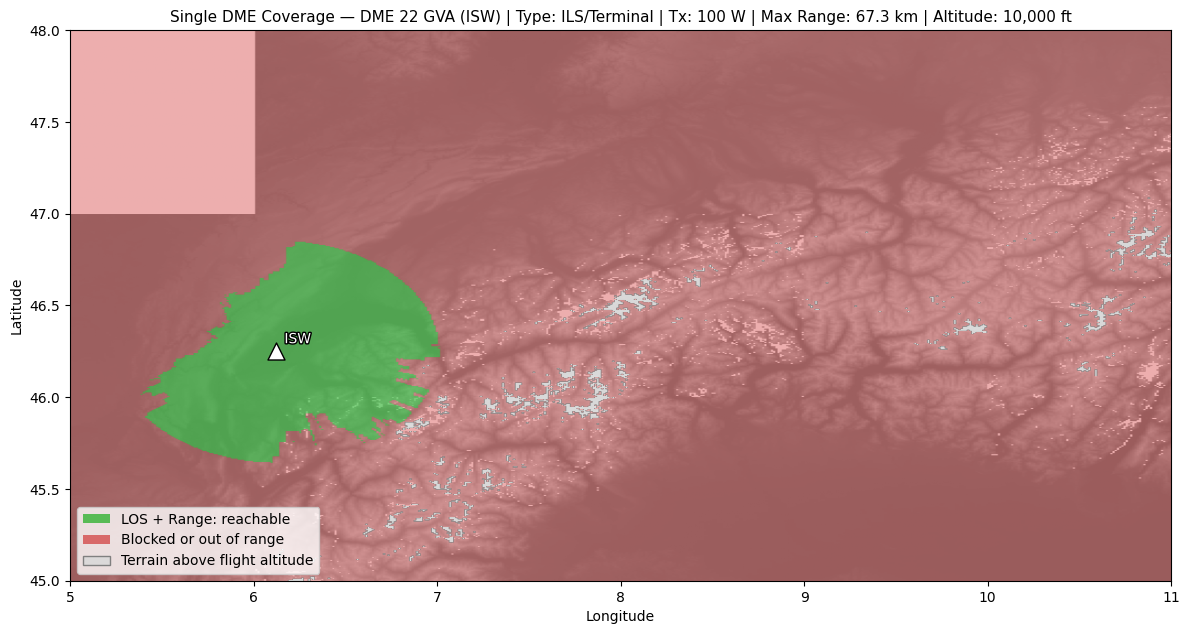

In [17]:
import matplotlib.patheffects as pe

dme_idx = 15  # ← Change to inspect other stations
dme     = df_ch.iloc[dme_idx]

# ── Build per-station combined mask ───────────────────────────────────────
# los_and_range[i]: True where LOS clear AND within max range for DME i
single_coverage = los_and_range[dme_idx].astype(float)  # float to support NaN

# Mask out terrain above flight altitude
single_coverage[terrain_mask] = np.nan

# ── RGBA overlay ───────────────────────────────────────────────────────────
coverage_rgba = np.zeros((*single_coverage.shape, 4))
coverage_rgba[single_coverage == 1]  = [0.2, 0.7, 0.2, 0.65]  # Green  — reachable
coverage_rgba[single_coverage == 0]  = [0.8, 0.1, 0.1, 0.35]  # Red    — blocked / out of range
# NaN pixels (terrain mask) remain fully transparent (alpha = 0)

fig, ax = plt.subplots(figsize=(12, 9))

# Greyscale terrain background
ax.imshow(
    elev_grid,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    cmap="gray", origin="upper", alpha=0.5
)

# Terrain-above-flight-altitude overlay (light grey)
terrain_rgba = np.zeros((*terrain_mask.shape, 4))
terrain_rgba[terrain_mask] = [0.85, 0.85, 0.85, 0.85]  # Light grey
ax.imshow(
    terrain_rgba,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    origin="upper"
)

# Coverage overlay
ax.imshow(
    coverage_rgba,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    origin="upper"
)

# DME station marker
ax.scatter(dme["lon"], dme["lat"], color="white", s=150, zorder=5, marker="^",
           edgecolors="black", linewidths=1.0)
ax.annotate(
    dme["Identification"],
    (dme["lon"], dme["lat"]),
    textcoords="offset points", xytext=(6, 6),
    fontsize=10, color="white",
    path_effects=[pe.withStroke(linewidth=2, foreground="black")]
)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=(0.2, 0.7, 0.2, 0.8), label="LOS + Range: reachable"),
    Patch(facecolor=(0.8, 0.1, 0.1, 0.6), label="Blocked or out of range"),
    Patch(facecolor=(0.85, 0.85, 0.85, 0.85), edgecolor="grey",
          label="Terrain above flight altitude"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=10)

ax.set_title(
    f"Single DME Coverage — {dme['Name']} ({dme['Identification']}) | "
    f"Type: {dme['DME Type']} | Tx: {dme['Transmit Power (W)']} W | "
    f"Max Range: {dme['Max Range (km)']:.1f} km | "
    f"Altitude: {FLIGHT_ALT_FT:,} ft",
    fontsize=11
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

---
## 18. Continuous Color Scale Coverage Map

Quick overview using a continuous **Red-Yellow-Green** colormap (`RdYlGn`):
- 🔴 Red → few or no DMEs
- 🟡 Yellow → moderate coverage
- 🟢 Green → many DMEs available

Grid points where the terrain exceeds the flight altitude are shown in **light grey**  
(physically unreachable — inside a mountain).

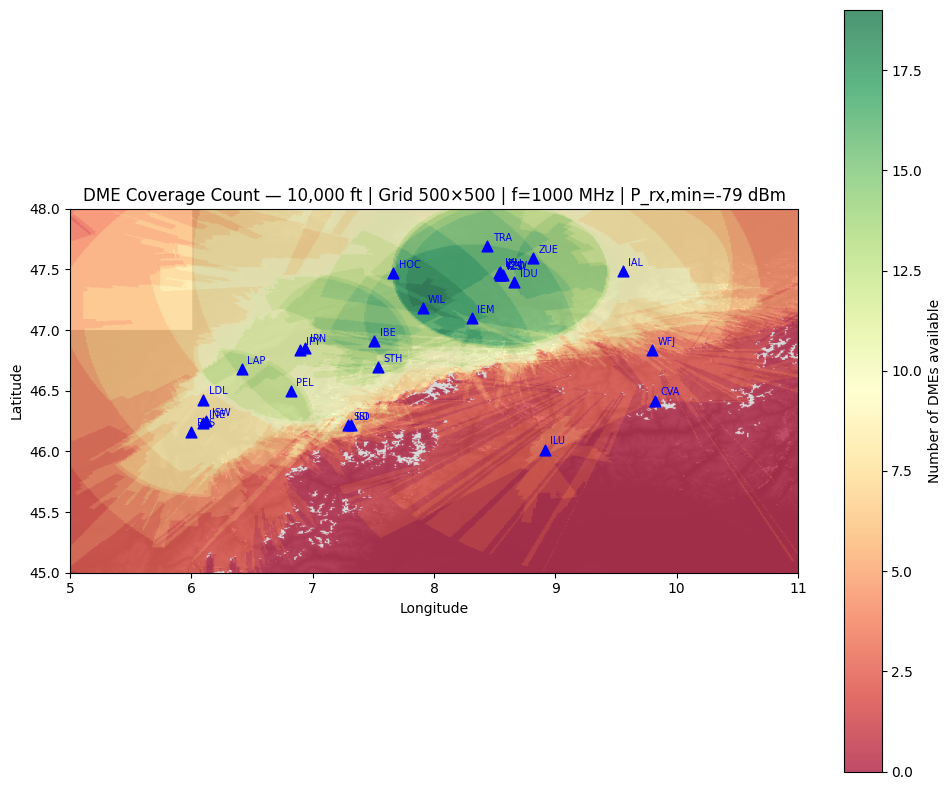

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))

# Grayscale terrain as background reference layer
ax.imshow(
    elev_grid,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    cmap="gray", origin="upper", alpha=0.4
)

# DME count heatmap — NaN values (terrain > flight alt) rendered as light grey
cmap_cont = plt.cm.RdYlGn.copy()
cmap_cont.set_bad(color="lightgrey")  # Colour for NaN (terrain mask)

im = ax.imshow(
    dme_count_grid,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    cmap=cmap_cont, origin="upper", alpha=0.7,
    vmin=0, vmax=np.nanmax(dme_count_grid)
)

# Station markers
for _, dme in df_ch.iterrows():
    ax.scatter(dme["lon"], dme["lat"], color="blue", s=60, zorder=5, marker="^")
    ax.annotate(dme["Identification"], (dme["lon"], dme["lat"]),
                textcoords="offset points", xytext=(4, 4), fontsize=7, color="blue")

plt.colorbar(im, ax=ax, label="Number of DMEs available")
ax.set_title(
    f"DME Coverage Count — {FLIGHT_ALT_FT:,} ft | Grid {GRID_SIZE}×{GRID_SIZE} | "
    f"f={FREQ_HZ/1e6:.0f} MHz | P_rx,min={P_RX_MIN_DBM} dBm"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

---
## 19. Discrete Color Scale Coverage Map — Final Publication Plot

The same coverage data re-plotted with a **5-level discrete colormap** matching the  
aviation safety significance of each DME count level.  
Station identifiers use a black outline stroke for readability on any background.

| Color | Count | Meaning |
|---|---|---|
| ⬛ Dark grey | 0 | No signal — blind spot |
| 🔴 Red | 1 | Single point of failure |
| 🟠 Orange | 2 | Minimum redundancy |
| 🟢 Light green | 3 | Good coverage |
| 🟩 Dark green | 4+ | Excellent redundancy |
| ◻️ Light grey | — | Terrain above flight altitude (excluded) |

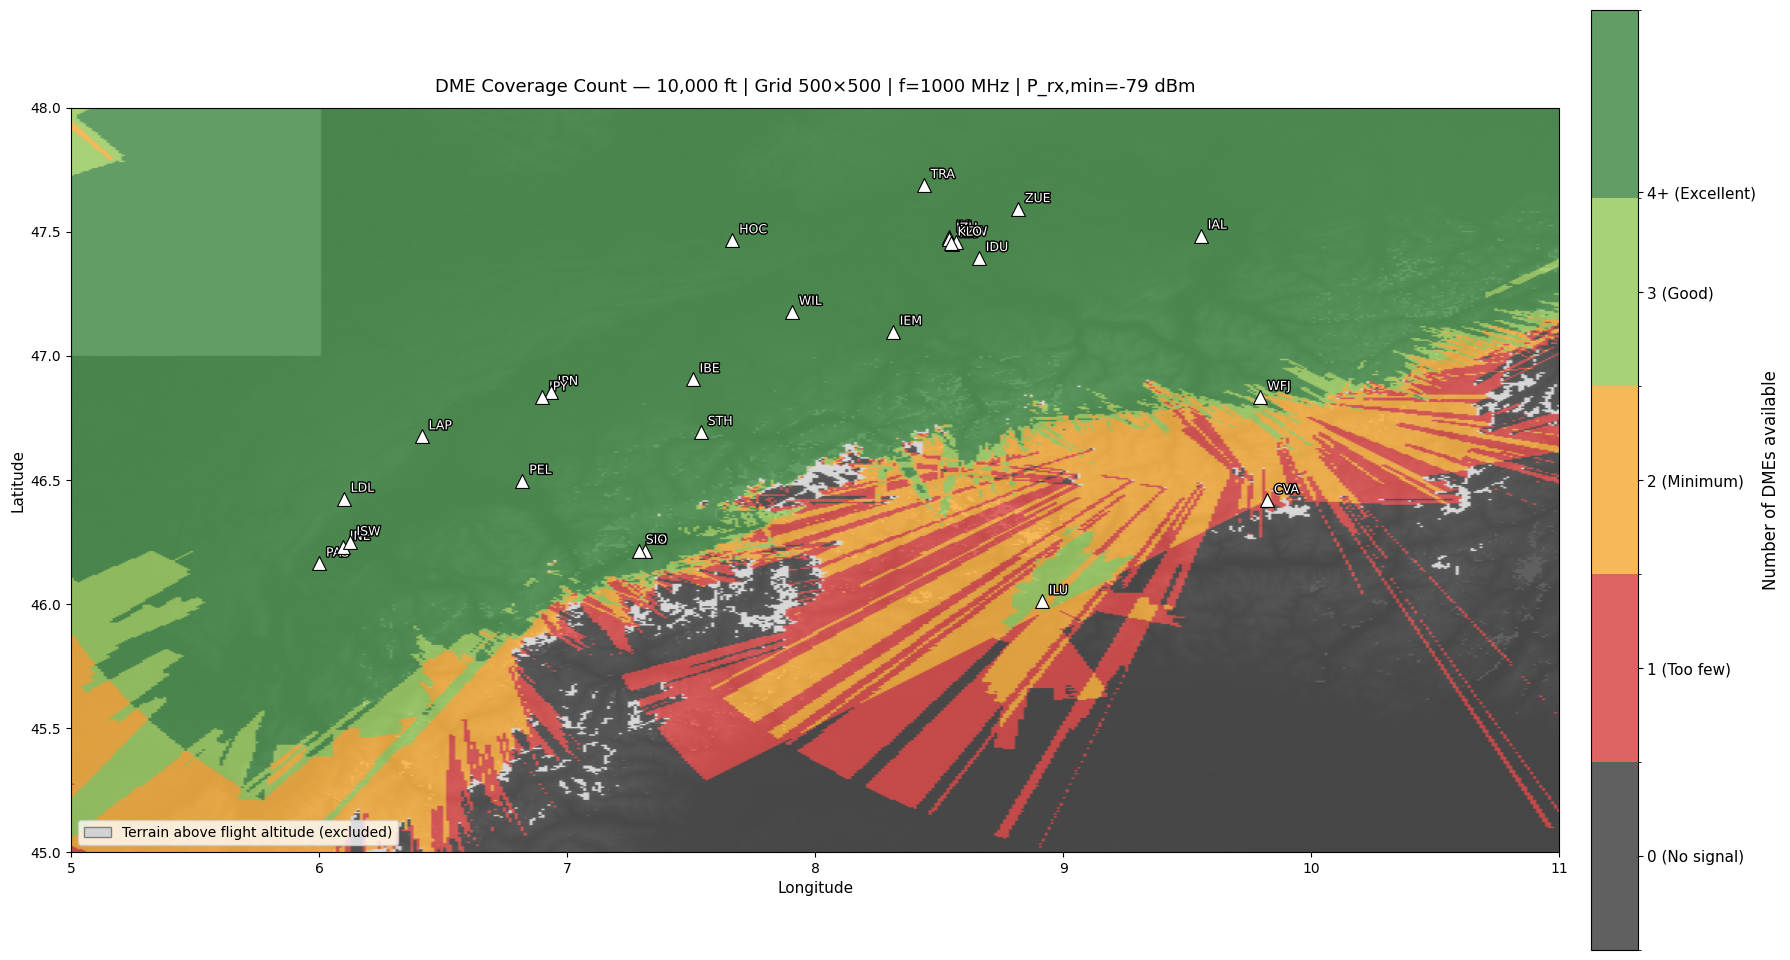

In [19]:
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe

# 5-class discrete colormap
cmap_disc = mcolors.ListedColormap(["#2b2b2b", "#d32f2f", "#f4a020", "#8bc34a", "#2e7d32"])
cmap_disc.set_bad(color="lightgrey")  # NaN (terrain mask) rendered as light grey

bounds_cmap = [0, 1, 2, 3, 4, np.nanmax(dme_count_grid) + 1]
norm = mcolors.BoundaryNorm(bounds_cmap, cmap_disc.N)

fig, ax = plt.subplots(figsize=(18, 14))

# Grayscale terrain background
ax.imshow(
    elev_grid,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    cmap="gray", origin="upper", alpha=0.4
)

# Discrete DME count overlay — NaN shown as light grey via set_bad()
im = ax.imshow(
    dme_count_grid,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    cmap=cmap_disc, norm=norm, origin="upper", alpha=0.75
)

# Station markers: white fill, black edge for contrast on any background
for _, dme in df_ch.iterrows():
    ax.scatter(dme["lon"], dme["lat"], color="white", s=100, zorder=5, marker="^",
               edgecolors="black", linewidths=0.8)
    ax.annotate(
        dme["Identification"],
        (dme["lon"], dme["lat"]),
        textcoords="offset points", xytext=(5, 5),
        fontsize=9, color="white",
        path_effects=[pe.withStroke(linewidth=2, foreground="black")]  # Text outline
    )

# Colorbar with descriptive class labels
cbar = plt.colorbar(im, ax=ax, ticks=[0.5, 1.5, 2.5, 3.5, 4.5], fraction=0.03, pad=0.02)
cbar.ax.set_yticklabels([
    "0 (No signal)",
    "1 (Too few)",
    "2 (Minimum)",
    "3 (Good)",
    "4+ (Excellent)"
], fontsize=11)
cbar.set_label("Number of DMEs available", fontsize=12)

# Add a separate legend entry explaining the grey terrain areas
from matplotlib.patches import Patch
terrain_patch = Patch(facecolor="lightgrey", edgecolor="grey",
                      label="Terrain above flight altitude (excluded)")
ax.legend(handles=[terrain_patch], loc="lower left", fontsize=10)

ax.set_title(
    f"DME Coverage Count — {FLIGHT_ALT_FT:,} ft | Grid {GRID_SIZE}×{GRID_SIZE} | "
    f"f={FREQ_HZ/1e6:.0f} MHz | P_rx,min={P_RX_MIN_DBM} dBm",
    fontsize=13, pad=12
)
ax.set_xlabel("Longitude", fontsize=11)
ax.set_ylabel("Latitude", fontsize=11)
ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()

---
## 20. Spot Check — Lookup a Specific DME by Identifier

Quick filter to inspect all attributes of a specific DME station by its ICAO identification code.  
Example: `"ILU"` = ILS DME collocated at Lucerne / Beromünster area.


In [20]:
# Display full row(s) for the station with identification "ILU"
df_ch[df_ch["Identification"] == "ILU"]

,Master gUID,Identification,Name,Responsible State,Latitude,Longitude,Collocated VOR - Identification,Channel,Frequency of virtual VHF facility,UOM,...,Working hours,Effective date,Originator,lat,lon,DME Type,Transmit Power (W),Max Range (m),Max Range (km),Elevation (m)
3390,400001725651445,ILU,DME 01 LUG,SKYGUIDE,46.01146000N,008.91362000E,NaN,26X,NaN,NaN,...,NaN,10/07/2025,EUROCONTROL NMOC,46.01146,8.91362,ILS/Terminal,100,67283.936255,67.283936,300.0
